# Gross Data Comparison Analysis

This notebook compares different methods of calculating weekly gross to help decide which metric to use for predictions.

## Columns of Interest:
- `average_daily_gross_adjusted_2024`
- `average_daily_gross_per_theater_adjusted_2024`
- `total_gross_adjusted_2024`

## Key Questions:
1. **Method 1**: `total_gross_adjusted_2024 / days_in_release * 7` (average daily from total, then weekly)
2. **Method 2**: `average_daily_gross_adjusted_2024 * 7` (direct multiplication)
3. Which method is more reliable for weekly predictions?
4. Should we use day-of-week patterns for predictions?


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)


## 1. Load Dataset


In [17]:
# Load the dataset
df = pd.read_csv('../data/cleaned/final_merged_dataset_with_genres.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns related to gross/revenue:")
gross_cols = [c for c in df.columns if 'gross' in c.lower() or 'revenue' in c.lower() or 'weekly' in c.lower() or 'daily' in c.lower()]
for col in sorted(gross_cols):
    print(f"  - {col}")


Dataset shape: (4197, 113)

Columns related to gross/revenue:
  - average_daily_gross
  - average_daily_gross_adjusted_2024
  - average_daily_gross_per_theater
  - average_daily_gross_per_theater_adjusted_2024
  - average_weekly_gross
  - average_weekly_gross_adjusted_2024
  - average_weekly_gross_per_theater
  - average_weekly_gross_per_theater_adjusted_2024
  - avg_gross_friday
  - avg_gross_monday
  - avg_gross_saturday
  - avg_gross_sunday
  - avg_gross_thursday
  - avg_gross_tuesday
  - avg_gross_wednesday
  - avg_gross_weekday
  - avg_gross_weekend
  - gross
  - gross_adjusted_2024
  - gross_per_theater_by_total
  - gross_per_theater_by_total_adjusted_2024
  - revenue
  - revenue_adjusted_2024
  - total_gross
  - total_gross_adjusted_2024
  - total_gross_by_average_theaters
  - weekly_gross_by_total


## 2. Compare Two Methods of Calculating Weekly Gross

**Method 1**: `total_gross_adjusted_2024 / days_in_release * 7`  
**Method 2**: `average_daily_gross_adjusted_2024 * 7`


In [18]:
# Method 1: Calculate weekly gross from total_gross / days_in_release * 7
# First calculate average daily from total: total_gross / days_in_release
df['avg_daily_from_total'] = df['total_gross_adjusted_2024'] / df['days_in_release']
df['weekly_gross_method1'] = df['avg_daily_from_total'] * 7

# Method 2: Direct multiplication of average_daily_gross * 7
df['weekly_gross_method2'] = df['average_daily_gross_adjusted_2024'] * 7

# Filter to movies with all required data available
df_comparison = df[
    (df['total_gross_adjusted_2024'].notna()) & 
    (df['average_daily_gross_adjusted_2024'].notna()) &
    (df['days_in_release'].notna()) &
    (df['total_gross_adjusted_2024'] > 0) & 
    (df['average_daily_gross_adjusted_2024'] > 0) &
    (df['days_in_release'] > 0)
].copy()

print(f"Movies with all required data: {len(df_comparison):,}")
print(f"Total movies in dataset: {len(df):,}")
print(f"\nData availability:")
print(f"  total_gross_adjusted_2024: {df['total_gross_adjusted_2024'].notna().sum():,}")
print(f"  average_daily_gross_adjusted_2024: {df['average_daily_gross_adjusted_2024'].notna().sum():,}")
print(f"  days_in_release: {df['days_in_release'].notna().sum():,}")


Movies with all required data: 4,189
Total movies in dataset: 4,197

Data availability:
  total_gross_adjusted_2024: 4,197
  average_daily_gross_adjusted_2024: 4,197
  days_in_release: 4,197


## 3. Statistical Comparison


In [19]:
# Calculate ratio and difference between the two methods
df_comparison['ratio_method1_to_method2'] = df_comparison['weekly_gross_method1'] / df_comparison['weekly_gross_method2']
df_comparison['difference_methods'] = df_comparison['weekly_gross_method1'] - df_comparison['weekly_gross_method2']
df_comparison['pct_difference_methods'] = (df_comparison['difference_methods'] / df_comparison['weekly_gross_method1']) * 100

# Also compare the daily averages
df_comparison['ratio_daily_avg'] = df_comparison['avg_daily_from_total'] / df_comparison['average_daily_gross_adjusted_2024']

print("STATISTICAL COMPARISON: TWO METHODS OF CALCULATING WEEKLY GROSS")
print("="*80)

print(f"\nMethod 1: total_gross_adjusted_2024 / days_in_release * 7")
print(f"  Mean: ${df_comparison['weekly_gross_method1'].mean():,.2f}")
print(f"  Median: ${df_comparison['weekly_gross_method1'].median():,.2f}")
print(f"  Std: ${df_comparison['weekly_gross_method1'].std():,.2f}")
print(f"  Min: ${df_comparison['weekly_gross_method1'].min():,.2f}")
print(f"  Max: ${df_comparison['weekly_gross_method1'].max():,.2f}")

print(f"\nMethod 2: average_daily_gross_adjusted_2024 * 7")
print(f"  Mean: ${df_comparison['weekly_gross_method2'].mean():,.2f}")
print(f"  Median: ${df_comparison['weekly_gross_method2'].median():,.2f}")
print(f"  Std: ${df_comparison['weekly_gross_method2'].std():,.2f}")
print(f"  Min: ${df_comparison['weekly_gross_method2'].min():,.2f}")
print(f"  Max: ${df_comparison['weekly_gross_method2'].max():,.2f}")

print(f"\nComparison:")
print(f"  Ratio (Method 1 / Method 2):")
print(f"    Mean: {df_comparison['ratio_method1_to_method2'].mean():.3f}")
print(f"    Median: {df_comparison['ratio_method1_to_method2'].median():.3f}")
print(f"    Std: {df_comparison['ratio_method1_to_method2'].std():.3f}")
print(f"    Min: {df_comparison['ratio_method1_to_method2'].min():.3f}")
print(f"    Max: {df_comparison['ratio_method1_to_method2'].max():.3f}")

print(f"\n  Percentage Difference:")
print(f"    Mean: {df_comparison['pct_difference_methods'].mean():.2f}%")
print(f"    Median: {df_comparison['pct_difference_methods'].median():.2f}%")
print(f"    Std: {df_comparison['pct_difference_methods'].std():.2f}%")

# Correlation
correlation = df_comparison['weekly_gross_method1'].corr(df_comparison['weekly_gross_method2'])
print(f"\n  Correlation between Method 1 and Method 2: {correlation:.4f}")

print(f"\n\nDAILY AVERAGE COMPARISON:")
print(f"  avg_daily_from_total (total_gross / days_in_release):")
print(f"    Mean: ${df_comparison['avg_daily_from_total'].mean():,.2f}")
print(f"    Median: ${df_comparison['avg_daily_from_total'].median():,.2f}")

print(f"\n  average_daily_gross_adjusted_2024:")
print(f"    Mean: ${df_comparison['average_daily_gross_adjusted_2024'].mean():,.2f}")
print(f"    Median: ${df_comparison['average_daily_gross_adjusted_2024'].median():,.2f}")

print(f"\n  Ratio (avg_daily_from_total / average_daily_gross_adjusted_2024):")
print(f"    Mean: {df_comparison['ratio_daily_avg'].mean():.3f}")
print(f"    Median: {df_comparison['ratio_daily_avg'].median():.3f}")


STATISTICAL COMPARISON: TWO METHODS OF CALCULATING WEEKLY GROSS

Method 1: total_gross_adjusted_2024 / days_in_release * 7
  Mean: $5,963,442.37
  Median: $3,131,125.75
  Std: $7,998,712.55
  Min: $241.63
  Max: $98,267,441.86

Method 2: average_daily_gross_adjusted_2024 * 7
  Mean: $6,669,004.03
  Median: $3,447,735.59
  Std: $8,788,369.60
  Min: $110.50
  Max: $71,291,421.78

Comparison:
  Ratio (Method 1 / Method 2):
    Mean: 1.520
    Median: 1.000
    Std: 9.485
    Min: 0.002
    Max: 380.149

  Percentage Difference:
    Mean: -71.06%
    Median: -0.00%
    Std: 1544.49%

  Correlation between Method 1 and Method 2: 0.9567


DAILY AVERAGE COMPARISON:
  avg_daily_from_total (total_gross / days_in_release):
    Mean: $851,920.34
    Median: $447,303.68

  average_daily_gross_adjusted_2024:
    Mean: $952,714.86
    Median: $492,533.66

  Ratio (avg_daily_from_total / average_daily_gross_adjusted_2024):
    Mean: 1.520
    Median: 1.000


## 4. Visual Comparison


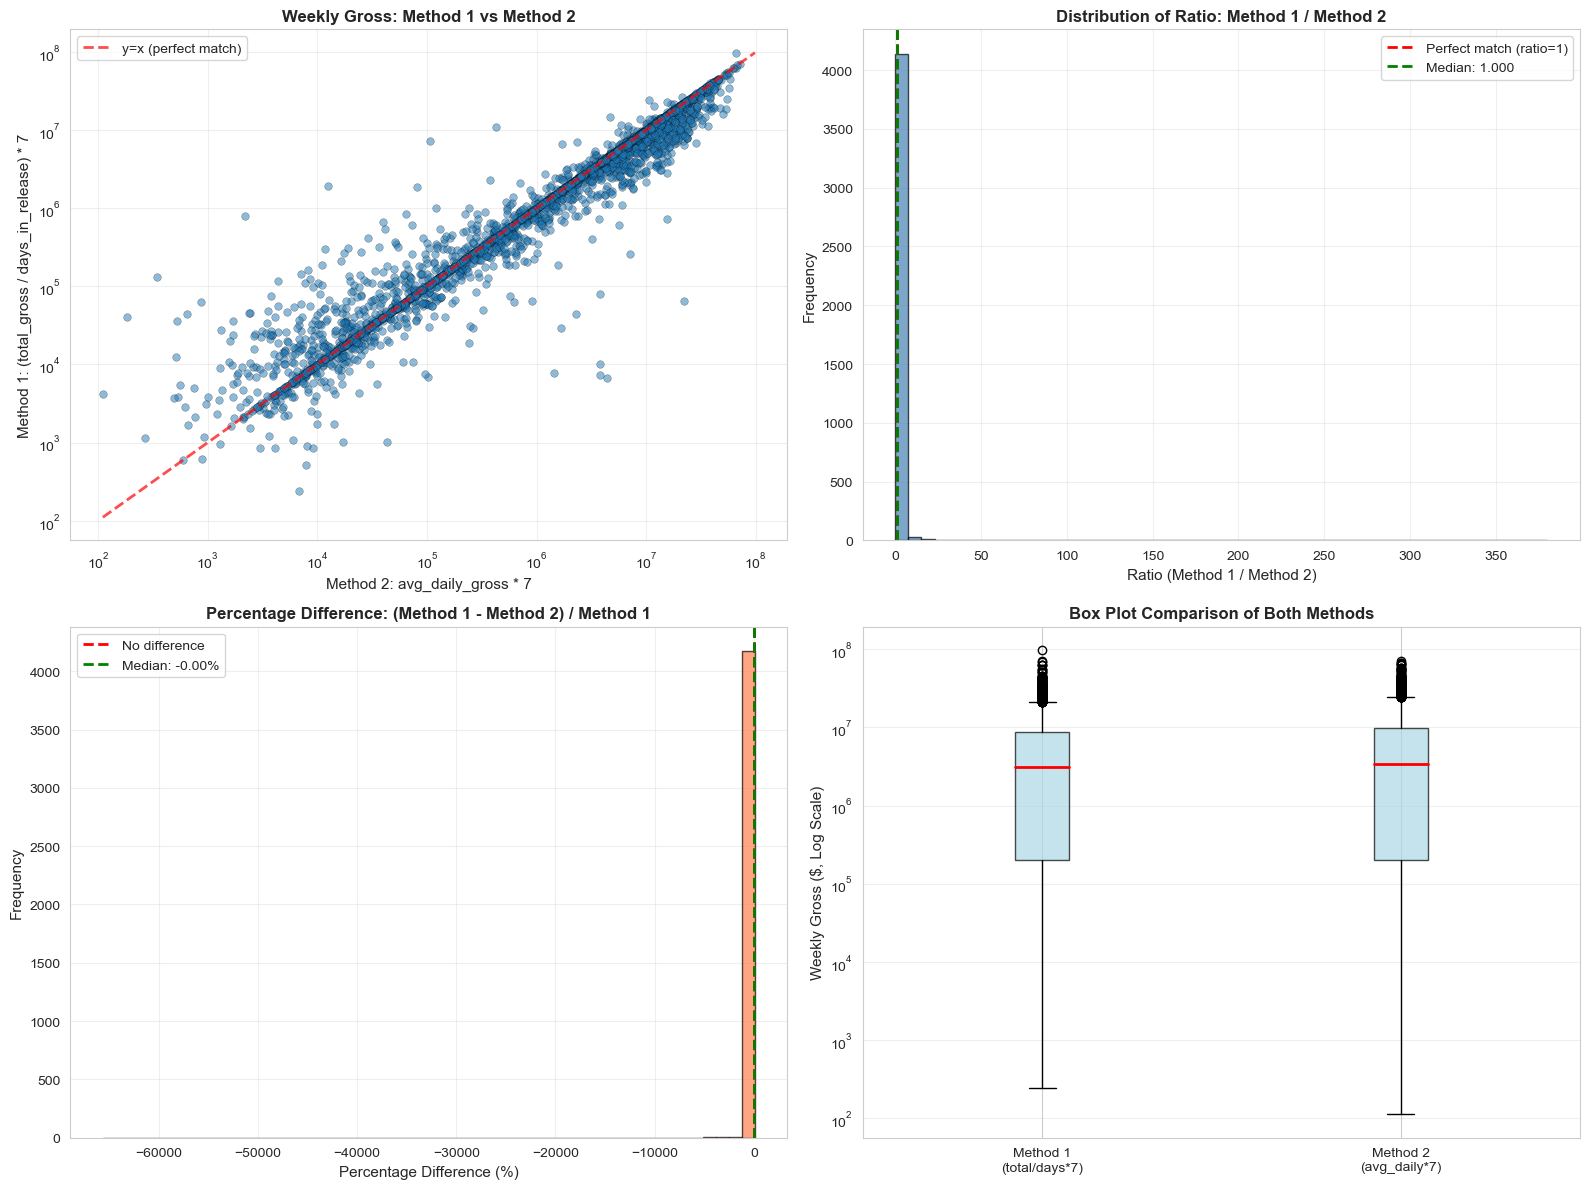

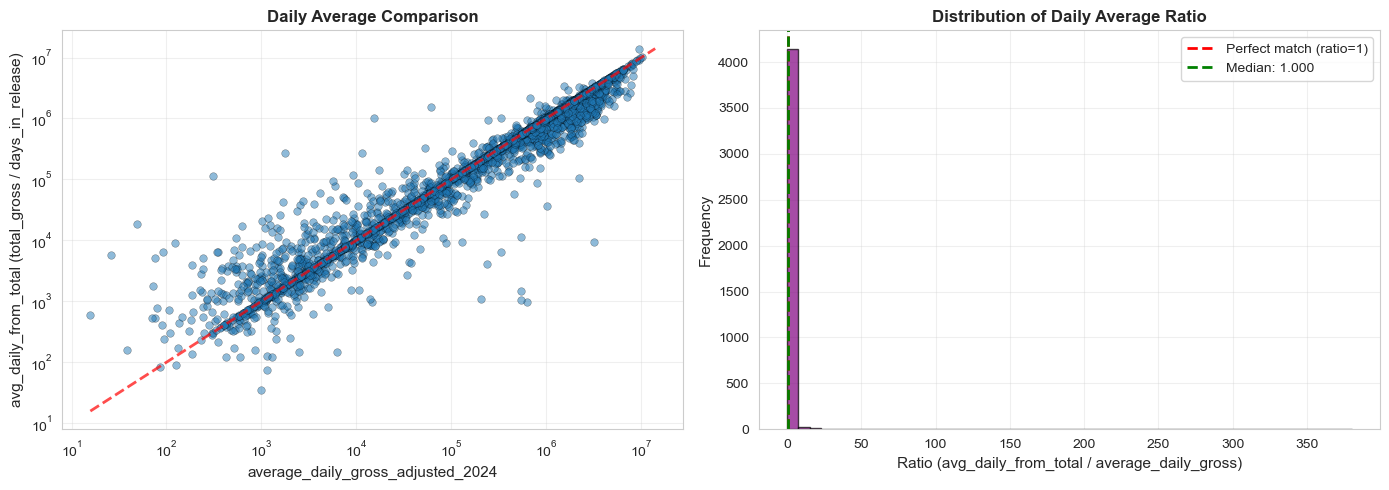

In [20]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter plot: Method 1 vs Method 2
ax1 = axes[0, 0]
ax1.scatter(df_comparison['weekly_gross_method2'], df_comparison['weekly_gross_method1'], 
           alpha=0.5, s=30, edgecolors='black', linewidth=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Method 2: avg_daily_gross * 7', fontsize=11)
ax1.set_ylabel('Method 1: (total_gross / days_in_release) * 7', fontsize=11)
ax1.set_title('Weekly Gross: Method 1 vs Method 2', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add diagonal line (y=x)
min_val = min(df_comparison['weekly_gross_method2'].min(), df_comparison['weekly_gross_method1'].min())
max_val = max(df_comparison['weekly_gross_method2'].max(), df_comparison['weekly_gross_method1'].max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, linewidth=2, label='y=x (perfect match)')
ax1.legend()

# 2. Distribution of ratio
ax2 = axes[0, 1]
ax2.hist(df_comparison['ratio_method1_to_method2'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(1, color='red', linestyle='--', linewidth=2, label='Perfect match (ratio=1)')
ax2.axvline(df_comparison['ratio_method1_to_method2'].median(), color='green', 
           linestyle='--', linewidth=2, label=f'Median: {df_comparison["ratio_method1_to_method2"].median():.3f}')
ax2.set_xlabel('Ratio (Method 1 / Method 2)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of Ratio: Method 1 / Method 2', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Percentage difference distribution
ax3 = axes[1, 0]
ax3.hist(df_comparison['pct_difference_methods'], bins=50, edgecolor='black', alpha=0.7, color='coral')
ax3.axvline(0, color='red', linestyle='--', linewidth=2, label='No difference')
ax3.axvline(df_comparison['pct_difference_methods'].median(), color='green', 
           linestyle='--', linewidth=2, label=f'Median: {df_comparison["pct_difference_methods"].median():.2f}%')
ax3.set_xlabel('Percentage Difference (%)', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Percentage Difference: (Method 1 - Method 2) / Method 1', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Box plot comparison
ax4 = axes[1, 1]
data_to_plot = [
    df_comparison['weekly_gross_method1'],
    df_comparison['weekly_gross_method2']
]
bp = ax4.boxplot(data_to_plot, labels=['Method 1\n(total/days*7)', 'Method 2\n(avg_daily*7)'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
ax4.set_yscale('log')
ax4.set_ylabel('Weekly Gross ($, Log Scale)', fontsize=11)
ax4.set_title('Box Plot Comparison of Both Methods', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Additional: Daily average comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: daily averages
ax1 = axes[0]
ax1.scatter(df_comparison['average_daily_gross_adjusted_2024'], df_comparison['avg_daily_from_total'],
           alpha=0.5, s=30, edgecolors='black', linewidth=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('average_daily_gross_adjusted_2024', fontsize=11)
ax1.set_ylabel('avg_daily_from_total (total_gross / days_in_release)', fontsize=11)
ax1.set_title('Daily Average Comparison', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
min_val = min(df_comparison['average_daily_gross_adjusted_2024'].min(), df_comparison['avg_daily_from_total'].min())
max_val = max(df_comparison['average_daily_gross_adjusted_2024'].max(), df_comparison['avg_daily_from_total'].max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, linewidth=2)

# Ratio distribution
ax2 = axes[1]
ax2.hist(df_comparison['ratio_daily_avg'], bins=50, edgecolor='black', alpha=0.7, color='purple')
ax2.axvline(1, color='red', linestyle='--', linewidth=2, label='Perfect match (ratio=1)')
ax2.axvline(df_comparison['ratio_daily_avg'].median(), color='green', 
           linestyle='--', linewidth=2, label=f'Median: {df_comparison["ratio_daily_avg"].median():.3f}')
ax2.set_xlabel('Ratio (avg_daily_from_total / average_daily_gross)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of Daily Average Ratio', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Analysis by days_in_release

Check if the number of days in release affects the relationship between the two methods.


ANALYSIS BY DAYS IN RELEASE

Ratio statistics by days in release:
                mean    median        std  count
days_range                                      
0-7         1.167283  1.000000   0.624091    353
8-14        1.290932  1.000000   2.370782    322
15-30       1.733051  0.999857  14.463124    714
31-60       1.290742  0.994731   4.802477   1139
61-90       1.713087  0.998690  12.476003    863
91-120      1.698557  0.999986   9.037055    798
120+             NaN       NaN        NaN      0

Percentage difference by days in release:
                  mean    median          std  count
days_range                                          
0-7         -49.409964  0.000000   993.520834    353
8-14       -376.573524  0.000000  4651.182007    322
15-30       -58.460851 -0.014301  1288.292563    714
31-60       -38.567645 -0.529722   311.529257   1139
61-90       -24.751089 -0.131125   139.862429    863
91-120      -65.065269 -0.001435  1303.560964    798
120+               NaN    

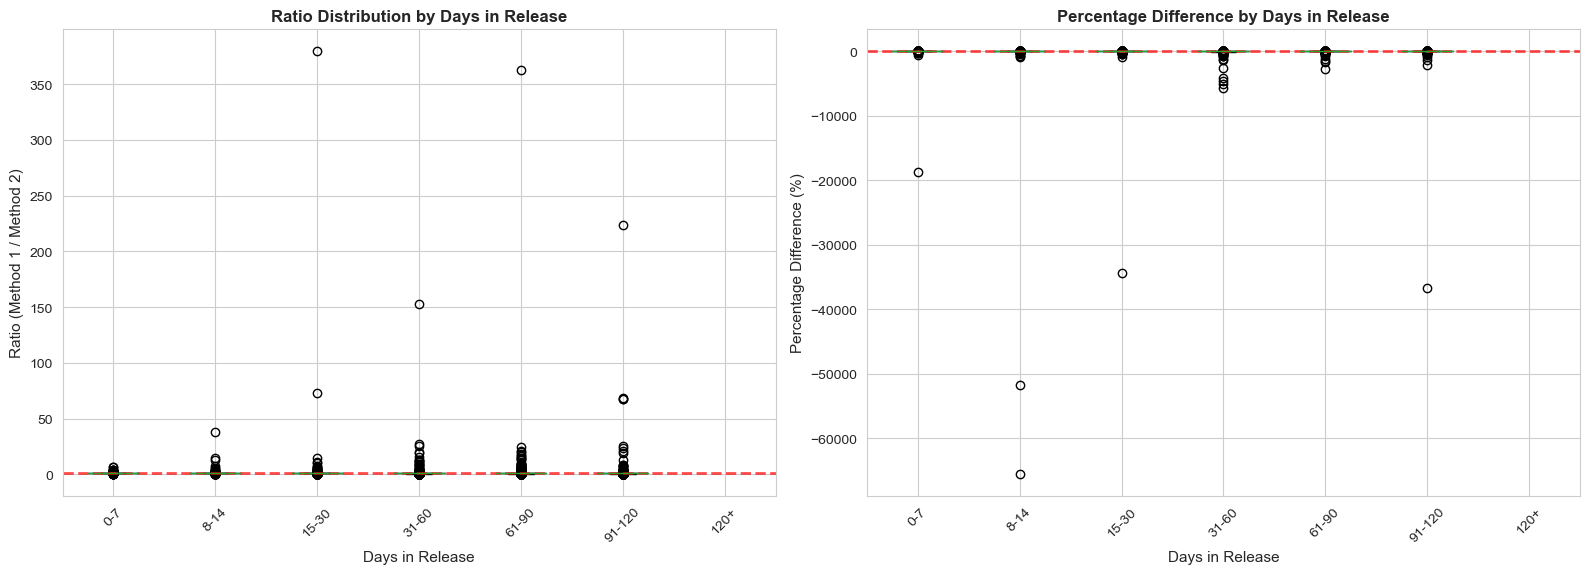


DAY-OF-WEEK PATTERN ANALYSIS
DAY-OF-WEEK PATTERN ANALYSIS

Found day-of-week columns: ['avg_gross_monday', 'avg_gross_tuesday', 'avg_gross_wednesday', 'avg_gross_thursday', 'avg_gross_friday', 'avg_gross_saturday', 'avg_gross_sunday', 'avg_gross_weekend', 'avg_gross_weekday']

Movies with weekend/weekday data: 4,197

Weekend vs Weekday Performance:
  Mean weekend gross: $1,259,981.35
  Mean weekday gross: $390,816.58
  Mean ratio (weekend/weekday): 3.84
  Median ratio: 3.29


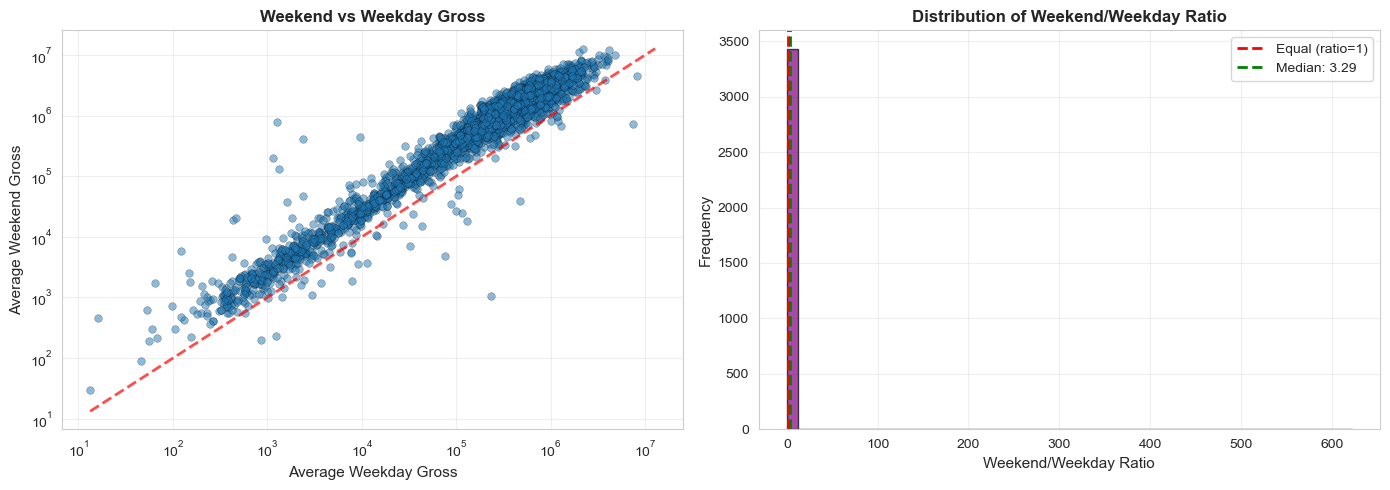



Average Gross by Day of Week:
  Monday: $365,169.71
  Tuesday: $410,085.09
  Wednesday: $367,555.20
  Thursday: $374,565.35
  Friday: $1,252,193.39
  Saturday: $1,544,995.96
  Sunday: $987,402.54


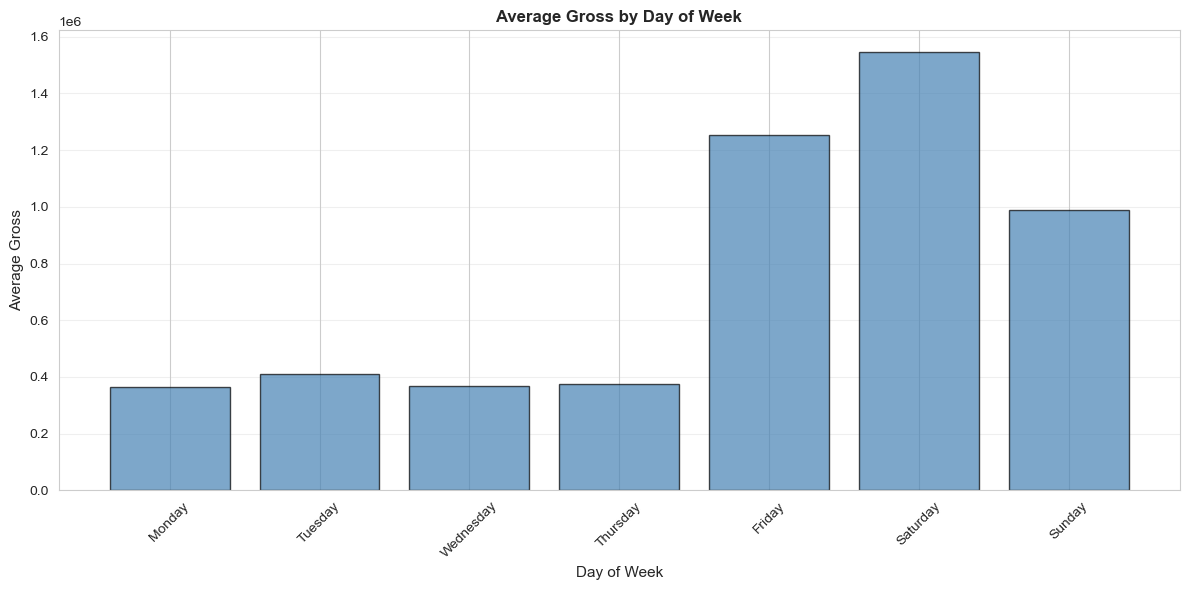

In [21]:
# Check if days_in_release affects the relationship
if 'days_in_release' in df_comparison.columns:
    print("ANALYSIS BY DAYS IN RELEASE")
    print("="*80)
    
    # Group by days_in_release ranges
    df_comparison['days_range'] = pd.cut(df_comparison['days_in_release'], 
                                        bins=[0, 7, 14, 30, 60, 90, 120, float('inf')],
                                        labels=['0-7', '8-14', '15-30', '31-60', '61-90', '91-120', '120+'])
    
    print("\nRatio statistics by days in release:")
    ratio_by_days = df_comparison.groupby('days_range')['ratio_method1_to_method2'].agg(['mean', 'median', 'std', 'count'])
    print(ratio_by_days)
    
    print("\nPercentage difference by days in release:")
    pct_diff_by_days = df_comparison.groupby('days_range')['pct_difference_methods'].agg(['mean', 'median', 'std', 'count'])
    print(pct_diff_by_days)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    df_comparison.boxplot(column='ratio_method1_to_method2', by='days_range', ax=axes[0])
    axes[0].set_xlabel('Days in Release', fontsize=11)
    axes[0].set_ylabel('Ratio (Method 1 / Method 2)', fontsize=11)
    axes[0].set_title('Ratio Distribution by Days in Release', fontsize=12, fontweight='bold')
    axes[0].axhline(1, color='red', linestyle='--', linewidth=2, alpha=0.7)
    plt.suptitle('')
    axes[0].tick_params(axis='x', rotation=45)
    
    df_comparison.boxplot(column='pct_difference_methods', by='days_range', ax=axes[1])
    axes[1].set_xlabel('Days in Release', fontsize=11)
    axes[1].set_ylabel('Percentage Difference (%)', fontsize=11)
    axes[1].set_title('Percentage Difference by Days in Release', fontsize=12, fontweight='bold')
    axes[1].axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    plt.suptitle('')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("days_in_release column not found in comparison dataset")

print("\n" + "="*80)
print("DAY-OF-WEEK PATTERN ANALYSIS")
print("="*80)

# Check if we have day-of-week averages
day_cols = [c for c in df.columns if 'avg_gross_' in c and ('monday' in c or 'tuesday' in c or 'wednesday' in c or 'thursday' in c or 'friday' in c or 'saturday' in c or 'sunday' in c or 'weekend' in c or 'weekday' in c)]

if day_cols:
    print("DAY-OF-WEEK PATTERN ANALYSIS")
    print("="*80)
    print(f"\nFound day-of-week columns: {day_cols}")
    
    # Get movies with day-of-week data
    df_days = df[df[day_cols].notna().any(axis=1)].copy()
    
    if 'avg_gross_weekend' in df_days.columns and 'avg_gross_weekday' in df_days.columns:
        print(f"\nMovies with weekend/weekday data: {len(df_days):,}")
        
        # Calculate weekend vs weekday ratio
        df_days_valid = df_days[
            (df_days['avg_gross_weekend'] > 0) & 
            (df_days['avg_gross_weekday'] > 0)
        ].copy()
        
        df_days_valid['weekend_weekday_ratio'] = df_days_valid['avg_gross_weekend'] / df_days_valid['avg_gross_weekday']
        
        print(f"\nWeekend vs Weekday Performance:")
        print(f"  Mean weekend gross: ${df_days_valid['avg_gross_weekend'].mean():,.2f}")
        print(f"  Mean weekday gross: ${df_days_valid['avg_gross_weekday'].mean():,.2f}")
        print(f"  Mean ratio (weekend/weekday): {df_days_valid['weekend_weekday_ratio'].mean():.2f}")
        print(f"  Median ratio: {df_days_valid['weekend_weekday_ratio'].median():.2f}")
        
        # Visualize
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Weekend vs Weekday scatter
        axes[0].scatter(df_days_valid['avg_gross_weekday'], df_days_valid['avg_gross_weekend'],
                       alpha=0.5, s=30, edgecolors='black', linewidth=0.3)
        axes[0].set_xscale('log')
        axes[0].set_yscale('log')
        axes[0].set_xlabel('Average Weekday Gross', fontsize=11)
        axes[0].set_ylabel('Average Weekend Gross', fontsize=11)
        axes[0].set_title('Weekend vs Weekday Gross', fontsize=12, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        
        # Add diagonal line
        min_val = min(df_days_valid['avg_gross_weekday'].min(), df_days_valid['avg_gross_weekend'].min())
        max_val = max(df_days_valid['avg_gross_weekday'].max(), df_days_valid['avg_gross_weekend'].max())
        axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, linewidth=2)
        
        # Ratio distribution
        axes[1].hist(df_days_valid['weekend_weekday_ratio'], bins=50, edgecolor='black', alpha=0.7, color='purple')
        axes[1].axvline(1, color='red', linestyle='--', linewidth=2, label='Equal (ratio=1)')
        axes[1].axvline(df_days_valid['weekend_weekday_ratio'].median(), color='green', 
                      linestyle='--', linewidth=2, label=f'Median: {df_days_valid["weekend_weekday_ratio"].median():.2f}')
        axes[1].set_xlabel('Weekend/Weekday Ratio', fontsize=11)
        axes[1].set_ylabel('Frequency', fontsize=11)
        axes[1].set_title('Distribution of Weekend/Weekday Ratio', fontsize=12, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Individual day analysis
        day_names = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
        day_cols_individual = [f'avg_gross_{day}' for day in day_names if f'avg_gross_{day}' in df_days.columns]
        
        if day_cols_individual:
            print(f"\n\nAverage Gross by Day of Week:")
            day_means = {}
            for col in day_cols_individual:
                day_data = df_days[df_days[col] > 0][col]
                if len(day_data) > 0:
                    day_name = col.replace('avg_gross_', '').title()
                    day_means[day_name] = day_data.mean()
            
            # Sort by day of week
            day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
            sorted_days = {k: day_means[k] for k in day_order if k in day_means}
            
            for day, mean_gross in sorted_days.items():
                print(f"  {day}: ${mean_gross:,.2f}")
            
            # Visualize
            fig, ax = plt.subplots(figsize=(12, 6))
            days = list(sorted_days.keys())
            means = list(sorted_days.values())
            ax.bar(days, means, color='steelblue', alpha=0.7, edgecolor='black')
            ax.set_xlabel('Day of Week', fontsize=11)
            ax.set_ylabel('Average Gross', fontsize=11)
            ax.set_title('Average Gross by Day of Week', fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
else:
    print("Day-of-week columns not found in dataset")


In [22]:
print("RECOMMENDATIONS FOR PREDICTION MODEL")
print("="*80)

print("\n1. CHOOSING BETWEEN THE TWO METHODS:")
print("   " + "-"*76)

median_ratio = df_comparison['ratio_method1_to_method2'].median()
mean_pct_diff = df_comparison['pct_difference_methods'].mean()
median_daily_ratio = df_comparison['ratio_daily_avg'].median()

print(f"   Method 1: total_gross_adjusted_2024 / days_in_release * 7")
print(f"   Method 2: average_daily_gross_adjusted_2024 * 7")
print(f"\n   Comparison Results:")
print(f"     - Median ratio (Method 1 / Method 2): {median_ratio:.3f}")
print(f"     - Mean percentage difference: {mean_pct_diff:.2f}%")
print(f"     - Daily average ratio: {median_daily_ratio:.3f}")

if abs(median_ratio - 1) < 0.1 and abs(mean_pct_diff) < 10:
    print("\n   ✓ The methods are very close (median ratio ≈ 1, mean difference < 10%)")
    print("   → RECOMMENDATION: Use Method 2 (average_daily_gross_adjusted_2024 * 7) because:")
    print("     - It's more transparent (we know exactly how it's calculated)")
    print("     - It's based on actual observed daily patterns across all reported dates")
    print("     - It can incorporate day-of-week effects")
    print("     - It doesn't depend on days_in_release which may vary")
elif abs(median_ratio - 1) < 0.2 and abs(mean_pct_diff) < 20:
    print("\n   ⚠️  The methods are relatively close but have some differences")
    print("   → RECOMMENDATION: Use Method 2, but investigate outliers")
    print("     - Method 2 is preferred for transparency")
    print("     - Check if differences are due to movies with few data points")
else:
    print(f"\n   ⚠️  The methods differ significantly (median ratio: {median_ratio:.3f}, mean diff: {mean_pct_diff:.2f}%)")
    print("   → RECOMMENDATION: Investigate why they differ")
    print("     - Check if days_in_release is accurate")
    print("     - Check if average_daily_gross is calculated correctly")
    print("     - Consider using Method 2 if it's more consistent")

print("\n2. INCORPORATING DAY-OF-WEEK PATTERNS:")
print("   " + "-"*76)

if 'avg_gross_weekend' in df.columns and 'avg_gross_weekday' in df.columns:
    df_valid_days = df[(df['avg_gross_weekend'] > 0) & (df['avg_gross_weekday'] > 0)]
    if len(df_valid_days) > 0:
        weekend_ratio = (df_valid_days['avg_gross_weekend'] / df_valid_days['avg_gross_weekday']).median()
        print(f"   ✓ Weekend/weekday ratio: {weekend_ratio:.2f} (weekends are {weekend_ratio:.1f}x higher)")
        print("   → RECOMMENDATION: Use day-of-week patterns in predictions")
        print("     - Predict daily demand separately for weekdays vs weekends")
        print("     - Or use weighted average: (5 * weekday_avg + 2 * weekend_avg) / 7")
    else:
        print("   ⚠️  Limited day-of-week data available")
else:
    print("   ⚠️  Day-of-week columns not available")

print("\n3. PREDICTION MODEL STRUCTURE:")
print("   " + "-"*76)
print("   Option A: Predict weekly demand directly")
print("     - Target: average_weekly_gross_adjusted_2024 or average_daily_gross_adjusted_2024 * 7")
print("     - Pros: Simpler, fewer predictions needed")
print("     - Cons: Loses day-of-week information")
print("\n   Option B: Predict daily demand, aggregate to weekly")
print("     - Target: average_daily_gross_adjusted_2024 (separate for weekdays/weekends)")
print("     - Pros: Can capture day-of-week patterns, more flexible")
print("     - Cons: More complex, need to handle missing days")
print("\n   → RECOMMENDATION: Start with Option A, then refine to Option B if needed")

print("\n4. FEATURES TO USE:")
print("   " + "-"*76)
print("   Primary target: average_daily_gross_adjusted_2024 (or * 7 for weekly)")
print("   Secondary: average_daily_gross_per_theater_adjusted_2024")
print("   If available: avg_gross_weekend, avg_gross_weekday (for day-of-week models)")
print("   Reference: total_gross_adjusted_2024 (for context, but not primary target)")


RECOMMENDATIONS FOR PREDICTION MODEL

1. CHOOSING BETWEEN THE TWO METHODS:
   ----------------------------------------------------------------------------
   Method 1: total_gross_adjusted_2024 / days_in_release * 7
   Method 2: average_daily_gross_adjusted_2024 * 7

   Comparison Results:
     - Median ratio (Method 1 / Method 2): 1.000
     - Mean percentage difference: -71.06%
     - Daily average ratio: 1.000

   ⚠️  The methods differ significantly (median ratio: 1.000, mean diff: -71.06%)
   → RECOMMENDATION: Investigate why they differ
     - Check if days_in_release is accurate
     - Check if average_daily_gross is calculated correctly
     - Consider using Method 2 if it's more consistent

2. INCORPORATING DAY-OF-WEEK PATTERNS:
   ----------------------------------------------------------------------------
   ✓ Weekend/weekday ratio: 3.29 (weekends are 3.3x higher)
   → RECOMMENDATION: Use day-of-week patterns in predictions
     - Predict daily demand separately for weekdays

In [23]:
# Create summary table
summary_data = {
    'Metric': [
        'total_gross_adjusted_2024',
        'average_daily_gross_adjusted_2024',
        'avg_daily_from_total (total/days)',
        'weekly_gross_method1 (total/days*7)',
        'weekly_gross_method2 (avg_daily*7)',
        'average_daily_gross_per_theater_adjusted_2024'
    ],
    'Mean': [
        df_comparison['total_gross_adjusted_2024'].mean(),
        df_comparison['average_daily_gross_adjusted_2024'].mean(),
        df_comparison['avg_daily_from_total'].mean(),
        df_comparison['weekly_gross_method1'].mean(),
        df_comparison['weekly_gross_method2'].mean(),
        df_comparison['average_daily_gross_per_theater_adjusted_2024'].mean() if 'average_daily_gross_per_theater_adjusted_2024' in df_comparison.columns else None
    ],
    'Median': [
        df_comparison['total_gross_adjusted_2024'].median(),
        df_comparison['average_daily_gross_adjusted_2024'].median(),
        df_comparison['avg_daily_from_total'].median(),
        df_comparison['weekly_gross_method1'].median(),
        df_comparison['weekly_gross_method2'].median(),
        df_comparison['average_daily_gross_per_theater_adjusted_2024'].median() if 'average_daily_gross_per_theater_adjusted_2024' in df_comparison.columns else None
    ],
    'Available': [
        df_comparison['total_gross_adjusted_2024'].notna().sum(),
        df_comparison['average_daily_gross_adjusted_2024'].notna().sum(),
        df_comparison['avg_daily_from_total'].notna().sum(),
        df_comparison['weekly_gross_method1'].notna().sum(),
        df_comparison['weekly_gross_method2'].notna().sum(),
        df_comparison['average_daily_gross_per_theater_adjusted_2024'].notna().sum() if 'average_daily_gross_per_theater_adjusted_2024' in df_comparison.columns else 0
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Mean'] = summary_df['Mean'].apply(lambda x: f"${x:,.2f}" if x is not None and not pd.isna(x) else "N/A")
summary_df['Median'] = summary_df['Median'].apply(lambda x: f"${x:,.2f}" if x is not None and not pd.isna(x) else "N/A")

print("SUMMARY STATISTICS")
print("="*80)
print(summary_df.to_string(index=False))


SUMMARY STATISTICS
                                       Metric           Mean         Median  Available
                    total_gross_adjusted_2024 $50,217,187.32 $18,338,816.54       4189
            average_daily_gross_adjusted_2024    $952,714.86    $492,533.66       4189
            avg_daily_from_total (total/days)    $851,920.34    $447,303.68       4189
          weekly_gross_method1 (total/days*7)  $5,963,442.37  $3,131,125.75       4189
           weekly_gross_method2 (avg_daily*7)  $6,669,004.03  $3,447,735.59       4189
average_daily_gross_per_theater_adjusted_2024        $825.32        $539.92       4189
